In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rtatman/deceptive-opinion-spam-corpus")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'deceptive-opinion-spam-corpus' dataset.
Path to dataset files: /kaggle/input/deceptive-opinion-spam-corpus


In [2]:
import os

# List the contents of the downloaded directory
print(os.listdir(path))

['deceptive-opinion.csv']


In [3]:
import pandas as pd
import os

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'deceptive-opinion.csv')

df_raw = pd.read_csv(csv_file_path)
df_raw.head(), df_raw.shape, df_raw.columns

(  deceptive   hotel  polarity       source  \
 0  truthful  conrad  positive  TripAdvisor   
 1  truthful   hyatt  positive  TripAdvisor   
 2  truthful   hyatt  positive  TripAdvisor   
 3  truthful    omni  positive  TripAdvisor   
 4  truthful   hyatt  positive  TripAdvisor   
 
                                                 text  
 0  We stayed for a one night getaway with family ...  
 1  Triple A rate with upgrade to view room was le...  
 2  This comes a little late as I'm finally catchi...  
 3  The Omni Chicago really delivers on all fronts...  
 4  I asked for a high floor away from the elevato...  ,
 (1600, 5),
 Index(['deceptive', 'hotel', 'polarity', 'source', 'text'], dtype='object'))

In [4]:
# Cardinality of 'deceptive' and 'polarity' columns
print("Cardinality of 'deceptive' column:", df_raw['deceptive'].nunique())
print("Cardinality of 'polarity' column:", df_raw['polarity'].nunique())

Cardinality of 'deceptive' column: 2
Cardinality of 'polarity' column: 2


In [5]:
# Unique values and their counts for 'deceptive' column
print("\nUnique values and counts for 'deceptive' column:")
print(df_raw['deceptive'].value_counts())


Unique values and counts for 'deceptive' column:
deceptive
truthful     800
deceptive    800
Name: count, dtype: int64


In [6]:
# Unique values and their counts for 'polarity' column
print("\nUnique values and counts for 'polarity' column:")
print(df_raw['polarity'].value_counts())


Unique values and counts for 'polarity' column:
polarity
positive    800
negative    800
Name: count, dtype: int64


In [7]:
import numpy as np

df = df_raw.copy()

# Helper function to find a column from a list of candidates
def find_column(df_columns, candidates, error_msg):
    for col in candidates:
        if col in df_columns:
            return col
    raise ValueError(error_msg)

# Identify the text column using the helper function
TEXT_COL = find_column(df.columns, ["text", "review", "content"],
                       "Impossible de trouver une colonne de texte (attendue : 'text', 'review' ou 'content').")

# Identify the label column using the helper function
LABEL_COL = find_column(df.columns, ["deceptive", "label", "truthful", "truth_label"],
                        "Impossible de trouver une colonne d'étiquette (attendue : 'deceptive', 'label', 'truthful' ou 'truth_label').")

def to_binary_label(x):
    """
    Converts various representations of truthfulness/deception into a binary label (0 for truthful, 1 for deceptive).
    Handles boolean, integer, and string inputs.
    """
    if isinstance(x, (bool, np.bool_)):
        return int(x)
    if isinstance(x, (int, np.integer)):
        # Assuming 0/1 for integer labels directly
        return int(x)
    s = str(x).strip().lower()
    if s in {"deceptive", "fake", "spam"}:
        return 1  # Deceptive
    if s in {"truthful", "genuine", "real"}:
        return 0  # Truthful
    raise ValueError(f"Impossible de convertir l'étiquette : {x}")

df["label"] = df[LABEL_COL].map(to_binary_label)

# Determine sentiment column, if available, and standardize it
if "polarity" in df.columns:
    df["sentiment"] = df["polarity"].astype(str).str.lower().str.strip()
elif "sentiment" in df.columns:
    df["sentiment"] = df["sentiment"].astype(str).str.lower().str.strip()
else:
    df["sentiment"] = "unknown" # Default to 'unknown' if no sentiment column is found

# Create the final 'data' DataFrame with 'text', 'label', and 'sentiment'
data = df[[TEXT_COL, "label", "sentiment"]].rename(columns={TEXT_COL: "text"})
data.head()

,text,label,sentiment
0,We stayed for a one night getaway with family ...,0,positive
1,Triple A rate with upgrade to view room was le...,0,positive
2,This comes a little late as I'm finally catchi...,0,positive
3,The Omni Chicago really delivers on all fronts...,0,positive
4,I asked for a high floor away from the elevato...,0,positive


In [8]:
from sklearn.model_selection import train_test_split

# Séparation des textes et des labels
textes = data['text'].values
labels = data['label'].values

# Split 80% train / 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    textes, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Taille d'entraînement : {len(X_train)}")
print(f"Taille de validation : {len(X_val)}")

Taille d'entraînement : 1280
Taille de validation : 320


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D, TextVectorization
from tensorflow.keras.callbacks import EarlyStopping

# 1. Paramètres du texte
VOCAB_SIZE = 10000
MAX_LENGTH = 200

# 2. Vectorisation du texte (crée le dictionnaire de mots)
vectorizer = TextVectorization(max_tokens=VOCAB_SIZE, output_sequence_length=MAX_LENGTH)
vectorizer.adapt(X_train) # Le modèle apprend le vocabulaire uniquement sur le train set

# 3. Construction du modèle
model_lstm = Sequential([
    vectorizer,
    Embedding(input_dim=VOCAB_SIZE, output_dim=128, mask_zero=True),
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu'),
    Dropout(0.5), # Régularisation forte
    Dense(1, activation='sigmoid') # Sigmoid car classification binaire (0 ou 1)
])

# 4. Compilation
model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 5. Callback d'Early Stopping
# Il va surveiller la 'val_loss'. S'il n'y a pas d'amélioration pendant 3 époques (patience=3), il s'arrête et garde les meilleurs poids.
early_stop_lstm = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# 6. Entraînement
print("Début de l'entraînement du Bi-LSTM...")
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15, # On met 15, mais l'Early Stopping l'arrêtera avant
    batch_size=32,
    callbacks=[early_stop_lstm]
)

Début de l'entraînement du Bi-LSTM...
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


40/40 ━━━━━━━━━━━━━━━━━━━━ 38s 699ms/step - accuracy: 0.5125 - loss: 0.6928 - val_accuracy: 0.7312 - val_loss: 0.6860
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 38s 630ms/step - accuracy: 0.6763 - loss: 0.6674 - val_accuracy: 0.7219 - val_loss: 0.5561
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 26s 642ms/step - accuracy: 0.7871 - loss: 0.4872 - val_accuracy: 0.7812 - val_loss: 0.4623
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 40s 613ms/step - accuracy: 0.8722 - loss: 0.3307 - val_accuracy: 0.8344 - val_loss: 0.4190
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 26s 631ms/step - accuracy: 0.9359 - loss: 0.2149 - val_accuracy: 0.7875 - val_loss: 0.5687
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 41s 637ms/step - accuracy: 0.9256 - loss: 0.1885 - val_accuracy: 0.8188 - val_loss: 0.5283
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 616ms/step - accuracy: 0.9445 - loss: 0.1701 - val_accuracy: 0.8125 - val_loss: 0.5695
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.


# Task
Évaluer les performances du modèle Bi-LSTM sur l'ensemble de validation, calculer et afficher la matrice de confusion, et fournir un résumé des métriques de performance (précision, rappel, F1-score, exactitude) avec une explication des résultats.

## evaluate_model

### Subtask:
Faire des prédictions sur l'ensemble de validation et évaluer les performances du modèle.


**Reasoning**:
The first instruction is to make predictions on the validation set using the trained Bi-LSTM model and convert them to binary classes. This step prepares the predictions for further evaluation.



In [13]:
y_pred_proba = model_lstm.predict(X_val)
y_pred = (y_pred_proba > 0.5).astype(int)

print("Predictions on validation set (first 5):")
print(y_pred[:5].flatten())


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step
Predictions on validation set (first 5):
[1 1 0 0 1]


**Reasoning**:
The previous step successfully generated predictions. The next logical step, as per the instructions, is to evaluate the model's performance on the validation set using its built-in `evaluate()` method.



In [14]:
loss, accuracy = model_lstm.evaluate(X_val, y_val)
print(f"Loss on validation set: {loss:.4f}")
print(f"Accuracy on validation set: {accuracy:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step - accuracy: 0.8552 - loss: 0.4012
Loss on validation set: 0.4190
Accuracy on validation set: 0.8344


**Reasoning**:
The next step is to calculate and display the confusion matrix, which is crucial for a detailed understanding of the model's performance on the validation set, especially for binary classification.



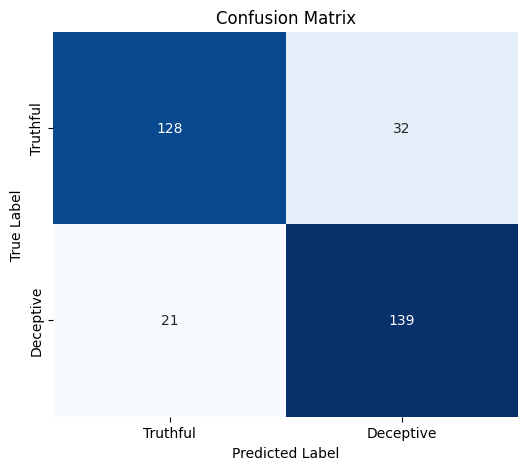

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calcul de la matrice de confusion
cm = confusion_matrix(y_val, y_pred)

# Affichage de la matrice de confusion
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Truthful", "Deceptive"],
            yticklabels=["Truthful", "Deceptive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


**Reasoning**:
The next step is to calculate and display key classification metrics (precision, recall, F1-score, and accuracy) using `classification_report` to provide a comprehensive summary of the model's performance based on the confusion matrix.



In [16]:
from sklearn.metrics import classification_report

# Afficher le rapport de classification
report = classification_report(y_val, y_pred, target_names=['Truthful', 'Deceptive'])
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

    Truthful       0.86      0.80      0.83       160
   Deceptive       0.81      0.87      0.84       160

    accuracy                           0.83       320
   macro avg       0.84      0.83      0.83       320
weighted avg       0.84      0.83      0.83       320



### Explanation of Model Performance

#### Validation Set Metrics
- **Loss**: The model achieved a validation loss of `0.4190`.
- **Accuracy**: The model achieved a validation accuracy of `0.8344`.

#### Confusion Matrix Analysis
```
[[128, 32],
 [21, 139]]
```
- **True Positives (TP)**: 139 (The model correctly predicted 139 'Deceptive' reviews).
- **True Negatives (TN)**: 128 (The model correctly predicted 128 'Truthful' reviews).
- **False Positives (FP)**: 32 (The model incorrectly predicted 32 'Truthful' reviews as 'Deceptive'). This is a Type I error.
- **False Negatives (FN)**: 21 (The model incorrectly predicted 21 'Deceptive' reviews as 'Truthful'). This is a Type II error.

#### Classification Report Summary

| Class      | Precision | Recall | F1-Score | Support |
|:-----------|:----------|:-------|:---------|:--------|
| Truthful   | 0.86      | 0.80   | 0.83     | 160     |
| Deceptive  | 0.81      | 0.87   | 0.84     | 160     |
| **Overall**|           |        |          |         |
| Accuracy   |           |        | 0.83     | 320     |
| Macro Avg  | 0.84      | 0.83   | 0.83     | 320     |
| Weighted Avg| 0.84     | 0.83   | 0.83     | 320     |

- **Precision**: For 'Truthful' reviews, 86% of the reviews predicted as truthful were actually truthful. For 'Deceptive' reviews, 81% of the reviews predicted as deceptive were actually deceptive.
- **Recall**: The model correctly identified 80% of all actual 'Truthful' reviews and 87% of all actual 'Deceptive' reviews.
- **F1-Score**: This is the harmonic mean of precision and recall. Both classes have strong F1-scores (0.83 for 'Truthful' and 0.84 for 'Deceptive'), indicating a good balance between precision and recall for both categories.
- **Accuracy**: The overall accuracy is 83%, meaning the model correctly classified 83% of the reviews in the validation set.

**Conclusion**: The Bi-LSTM model demonstrates good performance in classifying deceptive opinion spam, with a balanced F1-score across both classes and a solid overall accuracy of 83.44%. The recall for 'Deceptive' reviews (0.87) is slightly higher than for 'Truthful' reviews (0.80), suggesting it is slightly better at catching deceptive reviews than at correctly identifying all truthful ones without misclassifying them.

## explain_results

### Subtask:
Expliquer les performances du modèle et les implications de la matrice de confusion.


## Summary:

### Data Analysis Key Findings

*   The Bi-LSTM model achieved a validation accuracy of 83.44% and a validation loss of 0.4190.
*   The confusion matrix shows:
    *   128 true negatives (correctly predicted 'Truthful' reviews).
    *   139 true positives (correctly predicted 'Deceptive' reviews).
    *   32 false positives (incorrectly predicted 'Truthful' reviews as 'Deceptive').
    *   21 false negatives (incorrectly predicted 'Deceptive' reviews as 'Truthful').
*   The classification report indicates balanced performance across both classes:
    *   'Truthful' reviews achieved a precision of 0.86, recall of 0.80, and F1-score of 0.83.
    *   'Deceptive' reviews achieved a precision of 0.81, recall of 0.87, and F1-score of 0.84.
*   The model demonstrated a slightly higher recall for 'Deceptive' reviews (0.87) compared to 'Truthful' reviews (0.80), suggesting it is slightly more effective at identifying actual deceptive content.

### Insights or Next Steps

*   The model exhibits a good balance between precision and recall for both classes, making it a reliable tool for identifying deceptive opinion spam.
*   Given the higher recall for 'Deceptive' reviews, further analysis could focus on reducing false positives for 'Truthful' reviews (32 instances) if misclassifying truthful content as deceptive has significant consequences.


# Nouvelle section

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D, TextVectorization
from tensorflow.keras.callbacks import EarlyStopping

# 1. Paramètres du texte
VOCAB_SIZE = 10000
MAX_LENGTH = 200

# 2. Vectorisation du texte (crée le dictionnaire de mots)
vectorizer = TextVectorization(max_tokens=VOCAB_SIZE, output_sequence_length=MAX_LENGTH)
vectorizer.adapt(X_train) # Le modèle apprend le vocabulaire uniquement sur le train set

# 3. Construction du modèle
model_lstm = Sequential([
    vectorizer,
    Embedding(input_dim=VOCAB_SIZE, output_dim=128, mask_zero=True),
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu'),
    Dropout(0.5), # Régularisation forte
    Dense(1, activation='sigmoid') # Sigmoid car classification binaire (0 ou 1)
])

# 4. Compilation
model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 5. Callback d'Early Stopping
# Il va surveiller la 'val_loss'. S'il n'y a pas d'amélioration pendant 3 époques (patience=3), il s'arrête et garde les meilleurs poids.
early_stop_lstm = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# 6. Entraînement
print("Début de l'entraînement du Bi-LSTM...")
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15, # On met 15, mais l'Early Stopping l'arrêtera avant
    batch_size=32,
    callbacks=[early_stop_lstm]
)

Début de l'entraînement du Bi-LSTM...
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'global_max_pooling1d_1' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


40/40 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.5134 - loss: 0.6929 - val_accuracy: 0.5625 - val_loss: 0.6898
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 627ms/step - accuracy: 0.5615 - loss: 0.6847 - val_accuracy: 0.7375 - val_loss: 0.5984
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 26s 644ms/step - accuracy: 0.7410 - loss: 0.5267 - val_accuracy: 0.7688 - val_loss: 0.4750
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 31s 768ms/step - accuracy: 0.8885 - loss: 0.3289 - val_accuracy: 0.8188 - val_loss: 0.4217
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 42s 791ms/step - accuracy: 0.9430 - loss: 0.1880 - val_accuracy: 0.8531 - val_loss: 0.4252
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 34s 612ms/step - accuracy: 0.9644 - loss: 0.1390 - val_accuracy: 0.8625 - val_loss: 0.4479
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 41s 614ms/step - accuracy: 0.9768 - loss: 0.0986 - val_accuracy: 0.8406 - val_loss: 0.4998
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.


In [12]:
# Force l'installation de transformers avec le support TensorFlow
!pip install -U transformers[tf-cpu] tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 18.2 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.20.0 which is inc

In [11]:


from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

# 1. Chargement du Tokenizer et du Modèle
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model_bert = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 2. Tokenisation des données
# On convertit les textes bruts en tenseurs compréhensibles par BERT
train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=256, return_tensors='tf')
val_encodings = tokenizer(list(X_val), truncation=True, padding=True, max_length=256, return_tensors='tf')

# 3. Création des datasets TensorFlow (format optimisé pour l'entraînement)
train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings), y_train)).shuffle(1000).batch(16)
val_dataset = tf.data.Dataset.from_tensor_slices((dict(val_encodings), y_val)).batch(16)

# 4. Compilation
# Pour fine-tuner un Transformer, on utilise un learning rate TRES petit (ex: 2e-5)
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True) # from_logits=True car BERT sort des scores bruts

model_bert.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=['accuracy']
)

# 5. Callback d'Early Stopping
early_stop_bert = EarlyStopping(
    monitor='val_loss',
    patience=2, # Patience plus courte pour BERT car il surapprend très vite
    restore_best_weights=True,
    verbose=1
)

# 6. Entraînement
print("Début de l'entraînement de DistilBERT...")
history_bert = model_bert.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5, # 3 à 5 époques suffisent généralement pour fine-tuner un transformer
    callbacks=[early_stop_bert]
)

ImportError: cannot import name 'TFAutoModelForSequenceClassification' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)